# Experiment: SDPO vs best_ver Benchmark

Objective:
- Benchmark stage-2 SDPO runs against stage-1 `best_ver`-style runs with a shared, robust analysis pipeline.
- Separate **feature effect** (`SDPO on` vs `sanity GRPO`) from **system effect** (`stage-2 stack` vs `stage-1 baseline`).

What this notebook does:
- Auto-resolves run artifacts (`training_logs.jsonl`, `metrics.jsonl`, `config.json`) from run dirs or direct files.
- Handles old and new log schemas, with explicit coverage/source flags.
- Computes comparable metrics and 7-desiderata profiles.
- Adds bootstrap confidence intervals for mean differences vs a chosen reference run.


In [1]:
# Setup
from __future__ import annotations

from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    pass

pd.set_option('display.max_columns', 240)
pd.set_option('display.width', 260)


In [2]:
# Config
RUNS = [
    {
        'label': 'best_ver_stage1_ref',
        'path': Path('/home/silas/co-scientist-project/runs/2026/1/23(2)'),
    },
    {
        'label': 'sdpo_stage2',
        'path': Path('/home/silas/co-scientist-project/runs/2026/2/SDPO/27(rich)'),
    },
    {
        'label': 'grpo_sanity_stage2',
        'path': Path('/home/silas/co-scientist-project/runs/2026/2/SDPO/27(rich)(sanity check)'),
    },
]

REFERENCE_LABEL = 'best_ver_stage1_ref'
MAX_ROWS_PER_RUN = 80000  # None = full file scan
DEFAULT_MAX_WORDS = 750

WINDOW = 'auto'
AUTO_TARGET_WINDOWS = 25

BOOTSTRAP_SAMPLES = 3000
BOOTSTRAP_SEED = 7


In [3]:
# Robust helpers: artifact discovery, schema handling, desiderata parsing, aggregation
LOG_REL_CANDIDATES = [
    'train/training_logs.jsonl',
    'training_logs.jsonl',
    'train/batch_summary.jsonl',
    'batch_summary.jsonl',
]
METRICS_REL_CANDIDATES = ['metrics.jsonl', 'train/metrics.jsonl']
CONFIG_REL_CANDIDATES = ['config.json']

BATCH_KEY_CANDIDATES = ['batch_idx', 'batch', 'progress/batch', 'step', 'global_step']

TEXT_KEY_PRIORITY = [
    'grader_output',
    'grader_output_raw',
    'grader_response',
    'grade_output',
    'xml_output',
    'rubric_xml',
    'feedback_xml',
]

LIST_KEY_CANDIDATES = [
    'desiderata_levels',
    'desiderata_scores',
    'guideline_levels',
    'guideline_scores',
]

NUMERIC_DES_KEY_RE = re.compile(
    r'^(?:desiderata|guideline|d)[ _-]?(?:num)?[ _-]?([1-7])(?:[ _-]?(?:level|score))?$',
    re.IGNORECASE,
)

ITEM_RE = re.compile(r'<item\b[^>]*>(.*?)</item>', re.IGNORECASE | re.DOTALL)
DES_BLOCK_RE = re.compile(
    r'<desiderata(?:m)?\b[^>]*num\s*=\s*["\']?([1-7])["\']?[^>]*>(.*?)</desiderata(?:m)?>',
    re.IGNORECASE | re.DOTALL,
)
LEVEL_RE = re.compile(r'<level>\s*([0-3])\s*</level>', re.IGNORECASE)
BRACKET7_RE = re.compile(r'\[\s*([0-3](?:\s*,\s*[0-3]){6})\s*\]')

@dataclass
class ArtifactPaths:
    run_dir: Path
    log_path: Path | None
    metrics_path: Path | None
    config_path: Path | None

def _first_existing(base: Path, rel_candidates: list[str]) -> Path | None:
    for rel in rel_candidates:
        p = base / rel
        if p.exists() and p.is_file():
            return p
    return None

def resolve_artifacts(path_like: Path) -> ArtifactPaths:
    p = Path(path_like)
    if p.is_file():
        run_dir = p.parent
        log_path = p
    else:
        run_dir = p
        log_path = _first_existing(run_dir, LOG_REL_CANDIDATES)
        if log_path is None:
            # fallback recursive search by priority
            for rel in LOG_REL_CANDIDATES:
                candidates = sorted([x for x in run_dir.rglob(Path(rel).name) if x.is_file()])
                if candidates:
                    log_path = candidates[-1]
                    break

    metrics_path = _first_existing(run_dir, METRICS_REL_CANDIDATES)
    config_path = _first_existing(run_dir, CONFIG_REL_CANDIDATES)
    return ArtifactPaths(run_dir=run_dir, log_path=log_path, metrics_path=metrics_path, config_path=config_path)

def load_json(path: Path | None) -> dict:
    if path is None or not path.exists():
        return {}
    try:
        return json.loads(path.read_text(encoding='utf-8'))
    except Exception:
        return {}

def _to_float(v):
    try:
        return float(v)
    except Exception:
        return None

def _is_valid_level(v):
    return v is not None and 0.0 <= v <= 3.0

def _extract_solution_text(text: str) -> str | None:
    if not isinstance(text, str):
        return None
    m = re.search(r'<solution\b[^>]*>\s*(.*?)\s*</solution>', text, flags=re.IGNORECASE | re.DOTALL)
    if not m:
        return None
    sol = m.group(1).strip()
    return sol if sol else None

def infer_compliance_from_text(text: str, max_words: int) -> bool | None:
    sol = _extract_solution_text(text)
    if sol is None:
        return False
    return len(sol.split()) <= max_words

def get_batch_idx(row: dict) -> int | None:
    for k in BATCH_KEY_CANDIDATES:
        if k in row:
            try:
                return int(row[k])
            except Exception:
                pass
    for k, v in row.items():
        if 'batch' in str(k).lower():
            try:
                return int(v)
            except Exception:
                continue
    return None

def choose_text_payload(row: dict) -> str | None:
    for k in TEXT_KEY_PRIORITY:
        v = row.get(k)
        if isinstance(v, str) and v.strip():
            return v
    best = None
    for _, v in row.items():
        if isinstance(v, str) and len(v) > 20:
            looks_structured = ('<' in v and '>' in v) or ('desiderata' in v.lower())
            if not looks_structured:
                continue
            if best is None or len(v) > len(best):
                best = v
    return best

def extract_vector_from_direct_fields(row: dict) -> tuple[np.ndarray | None, str]:
    for k in LIST_KEY_CANDIDATES:
        val = row.get(k)
        if isinstance(val, list):
            nums = [_to_float(x) for x in val[:7]]
            if len(nums) == 7 and all(_is_valid_level(x) for x in nums):
                return np.asarray(nums, dtype=np.float32), f'direct_list:{k}'

    found = {}
    for k, v in row.items():
        m = NUMERIC_DES_KEY_RE.match(str(k))
        if not m:
            continue
        idx = int(m.group(1))
        fv = _to_float(v)
        if _is_valid_level(fv):
            found[idx] = fv
    if len(found) == 7:
        return np.asarray([found[i] for i in range(1, 8)], dtype=np.float32), 'direct_numeric_fields'

    return None, 'none'

def extract_levels_from_des_blocks(text: str) -> list[tuple[int, int]]:
    pairs = []
    for num_s, body in DES_BLOCK_RE.findall(text):
        m = LEVEL_RE.search(body)
        if not m:
            continue
        pairs.append((int(num_s), int(m.group(1))))
    return pairs

def extract_item_vectors(text: str) -> list[list[int]]:
    vectors = []
    for item_body in ITEM_RE.findall(text):
        pairs = extract_levels_from_des_blocks(item_body)
        if pairs:
            seen = {}
            for num, lvl in pairs:
                if num not in seen:
                    seen[num] = lvl
            if len(seen) == 7:
                vectors.append([seen[i] for i in range(1, 8)])
                continue
        lv = [int(x) for x in LEVEL_RE.findall(item_body)]
        if len(lv) >= 7:
            vectors.append(lv[:7])
    return vectors

def vectors_from_block_sequence(pairs: list[tuple[int, int]]) -> list[list[int]]:
    vecs = []
    cur = {}
    for num, lvl in pairs:
        if num in cur:
            if len(cur) == 7:
                vecs.append([cur[i] for i in range(1, 8)])
            cur = {}
        if num not in cur:
            cur[num] = lvl
        if len(cur) == 7:
            vecs.append([cur[i] for i in range(1, 8)])
            cur = {}

    if vecs:
        return vecs

    raw = [lvl for _, lvl in pairs]
    n = len(raw) // 7
    if n > 0:
        return [raw[i * 7:(i + 1) * 7] for i in range(n)]
    return []

def extract_vector_from_text(text: str) -> tuple[np.ndarray | None, str]:
    if not isinstance(text, str) or not text.strip():
        return None, 'none'

    item_vecs = extract_item_vectors(text)
    if item_vecs:
        return np.asarray(item_vecs, dtype=np.float32).mean(axis=0), 'item_blocks'

    pairs = extract_levels_from_des_blocks(text)
    if pairs:
        vecs = vectors_from_block_sequence(pairs)
        if vecs:
            return np.asarray(vecs, dtype=np.float32).mean(axis=0), 'block_sequence'

    levels = [int(x) for x in LEVEL_RE.findall(text)]
    n_items = len(levels) // 7
    if n_items > 0:
        trimmed = levels[: n_items * 7]
        arr = np.asarray(trimmed, dtype=np.float32).reshape(n_items, 7)
        return arr.mean(axis=0), 'global_levels'

    m = BRACKET7_RE.search(text)
    if m:
        arr = [float(x.strip()) for x in m.group(1).split(',')]
        if len(arr) == 7 and all(_is_valid_level(v) for v in arr):
            return np.asarray(arr, dtype=np.float32), 'bracket7'

    return None, 'none'

def summarize_metrics_file(metrics_path: Path | None) -> dict:
    if metrics_path is None or not metrics_path.exists():
        return {}

    rows = []
    with metrics_path.open('r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            s = line.strip()
            if not s:
                continue
            try:
                rows.append(json.loads(s))
            except json.JSONDecodeError:
                continue

    if not rows:
        return {}

    out = {'metrics_rows': len(rows)}
    last = rows[-1]
    key_map = {
        'reward_total': ['reward/total', 'reward/sample_mean_valid'],
        'rubric_mean': ['rubric/sample_mean_valid', 'rubric/sample_mean_all'],
        'trainability_pass_rate': ['samples/trainability_pass_rate'],
        'format_rate': ['format_rate'],
    }

    for out_key, candidates in key_map.items():
        val = None
        for k in candidates:
            if isinstance(last.get(k), (int, float)):
                val = float(last[k])
                break
        if val is not None:
            out[f'metrics_last/{out_key}'] = val

        values = []
        for r in rows:
            for k in candidates:
                if isinstance(r.get(k), (int, float)):
                    values.append(float(r[k]))
                    break
        if values:
            out[f'metrics_best/{out_key}'] = float(np.max(values))
            out[f'metrics_mean/{out_key}'] = float(np.mean(values))

    return out

def summarize_training_log(log_path: Path | None, *, max_rows: int | None, max_words: int):
    if log_path is None or not log_path.exists():
        return None, pd.DataFrame(), {}

    rows_seen = 0
    json_ok = 0

    parse_mode_counts = Counter()
    compliance_source_counts = Counter()

    rubric_scores = []
    final_rewards = []
    word_counts = []
    compliance_flags = []
    trainable_flags = []

    des_sum = np.zeros(7, dtype=np.float64)
    des_n = 0

    batch_sums = defaultdict(lambda: {'n': 0, 'rubric_sum': 0.0, 'reward_sum': 0.0, 'des_sum': np.zeros(7, dtype=np.float64), 'des_n': 0})

    with log_path.open('r', encoding='utf-8', errors='ignore') as f:
        for line_idx, line in enumerate(f, start=1):
            if max_rows is not None and line_idx > max_rows:
                break

            s = line.strip()
            if not s:
                continue
            rows_seen += 1

            try:
                row = json.loads(s)
                json_ok += 1
            except json.JSONDecodeError:
                parse_mode_counts['json_decode_error'] += 1
                continue

            batch_idx = get_batch_idx(row)

            rv = row.get('rubric_score')
            rubric = float(rv) if isinstance(rv, (int, float)) else None
            if rubric is not None:
                rubric_scores.append(rubric)

            fv = row.get('final_reward')
            reward = float(fv) if isinstance(fv, (int, float)) else None
            if reward is not None:
                final_rewards.append(reward)

            wc = row.get('word_count')
            if isinstance(wc, (int, float)):
                word_counts.append(float(wc))

            compliance = None
            if isinstance(row.get('is_compliant'), bool):
                compliance = bool(row['is_compliant'])
                compliance_source_counts['observed:is_compliant'] += 1
            elif isinstance(row.get('format_penalty'), (int, float)):
                compliance = float(row['format_penalty']) <= 1e-12
                compliance_source_counts['inferred:format_penalty'] += 1
            else:
                txt = row.get('policy_output')
                if isinstance(txt, str):
                    inferred = infer_compliance_from_text(txt, max_words=max_words)
                    if isinstance(inferred, bool):
                        compliance = inferred
                        compliance_source_counts['inferred:policy_output'] += 1

            if isinstance(compliance, bool):
                compliance_flags.append(float(compliance))

            trainable = row.get('is_trainable')
            if isinstance(trainable, bool):
                trainable_flags.append(float(trainable))

            vec, mode = extract_vector_from_direct_fields(row)
            if vec is None:
                payload = choose_text_payload(row)
                vec, mode = extract_vector_from_text(payload or '')
            parse_mode_counts[mode] += 1

            if vec is not None:
                des_sum += vec
                des_n += 1

            if batch_idx is not None:
                b = batch_sums[int(batch_idx)]
                b['n'] += 1
                if rubric is not None:
                    b['rubric_sum'] += rubric
                if reward is not None:
                    b['reward_sum'] += reward
                if vec is not None:
                    b['des_sum'] += vec
                    b['des_n'] += 1

    run_summary = {
        'log_rows_seen': rows_seen,
        'log_rows_json_ok': json_ok,
        'log_rows_with_rubric': len(rubric_scores),
        'log_rows_with_desiderata': des_n,
        'log_desiderata_coverage': (des_n / json_ok) if json_ok else np.nan,
        'mean_rubric_score': float(np.mean(rubric_scores)) if rubric_scores else np.nan,
        'mean_final_reward': float(np.mean(final_rewards)) if final_rewards else np.nan,
        'mean_word_count': float(np.mean(word_counts)) if word_counts else np.nan,
        'compliance_rate': float(np.mean(compliance_flags)) if compliance_flags else np.nan,
        'trainable_rate': float(np.mean(trainable_flags)) if trainable_flags else np.nan,
        'compliance_sources': dict(compliance_source_counts),
        'desiderata_parse_modes': dict(parse_mode_counts),
    }

    if des_n > 0:
        d_mean = des_sum / des_n
        for i in range(7):
            run_summary[f'd{i+1}_mean'] = float(d_mean[i])
    else:
        for i in range(7):
            run_summary[f'd{i+1}_mean'] = np.nan

    batch_rows = []
    for bidx in sorted(batch_sums.keys()):
        b = batch_sums[bidx]
        n = max(int(b['n']), 1)
        rec = {
            'batch_idx': bidx,
            'n_samples': int(b['n']),
            'rubric_mean': b['rubric_sum'] / n,
            'reward_mean': b['reward_sum'] / n,
        }
        if int(b['des_n']) > 0:
            d_batch = b['des_sum'] / float(b['des_n'])
            for i in range(7):
                rec[f'd{i+1}_mean'] = float(d_batch[i])
        else:
            for i in range(7):
                rec[f'd{i+1}_mean'] = np.nan
        batch_rows.append(rec)

    batch_df = pd.DataFrame(batch_rows)
    arrays = {
        'rubric': np.asarray(rubric_scores, dtype=np.float64),
        'reward': np.asarray(final_rewards, dtype=np.float64),
        'compliance': np.asarray(compliance_flags, dtype=np.float64),
        'trainable': np.asarray(trainable_flags, dtype=np.float64),
    }

    return run_summary, batch_df, arrays


In [4]:
# Run benchmark extraction
records = []
details = {}

for spec in RUNS:
    label = spec['label']
    art = resolve_artifacts(spec['path'])
    cfg = load_json(art.config_path)

    max_words = int(cfg.get('max_word_count', DEFAULT_MAX_WORDS))
    log_summary, batch_df, arrays = summarize_training_log(
        art.log_path,
        max_rows=MAX_ROWS_PER_RUN,
        max_words=max_words,
    )
    metrics_summary = summarize_metrics_file(art.metrics_path)

    rec = {
        'label': label,
        'run_dir': str(art.run_dir),
        'log_path': str(art.log_path) if art.log_path else '',
        'metrics_path': str(art.metrics_path) if art.metrics_path else '',
        'config_path': str(art.config_path) if art.config_path else '',
        'cfg/use_sdpo': cfg.get('use_sdpo', np.nan),
        'cfg/learning_rate': cfg.get('learning_rate', np.nan),
        'cfg/batch_size': cfg.get('batch_size', np.nan),
        'cfg/group_size': cfg.get('group_size', np.nan),
        'cfg/max_tokens': cfg.get('max_tokens', np.nan),
        'cfg/grader_max_tokens': cfg.get('grader_max_tokens', np.nan),
        'cfg/min_words': cfg.get('min_words', np.nan),
        'cfg/reward_mode': cfg.get('reward_mode', np.nan),
        'cfg/ml_data': cfg.get('ml_data', np.nan),
        'cfg/arxiv_data': cfg.get('arxiv_data', np.nan),
        'cfg/pubmed_data': cfg.get('pubmed_data', np.nan),
    }

    if isinstance(log_summary, dict):
        rec.update(log_summary)
    rec.update(metrics_summary)

    records.append(rec)
    details[label] = {
        'artifacts': art,
        'config': cfg,
        'batch_df': batch_df,
        'arrays': arrays,
    }

summary_df = pd.DataFrame(records)

core_cols = [
    'label',
    'cfg/use_sdpo',
    'mean_rubric_score',
    'mean_final_reward',
    'compliance_rate',
    'trainable_rate',
    'mean_word_count',
    'd1_mean','d2_mean','d3_mean','d4_mean','d5_mean','d6_mean','d7_mean',
    'metrics_last/reward_total',
    'metrics_best/reward_total',
    'metrics_last/trainability_pass_rate',
    'metrics_last/format_rate',
    'log_rows_json_ok',
    'log_desiderata_coverage',
]
existing_core = [c for c in core_cols if c in summary_df.columns]
display(summary_df[existing_core].round(4))


,label,cfg/use_sdpo,mean_rubric_score,mean_final_reward,compliance_rate,trainable_rate,mean_word_count,d1_mean,d2_mean,d3_mean,d4_mean,d5_mean,d6_mean,d7_mean,metrics_last/reward_total,metrics_best/reward_total,metrics_last/trainability_pass_rate,metrics_last/format_rate,log_rows_json_ok,log_desiderata_coverage
0,best_ver_stage1_ref,NaN,0.6631,0.6616,0.9859,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.6801,0.7116,NaN,NaN,44553,0.0000
1,sdpo_stage2,NaN,0.4420,0.4729,0.9690,0.9676,524.4754,1.5518,1.3862,1.4334,1.4671,1.5443,1.6115,1.6888,0.4047,0.6304,0.9316,0.0664,54784,0.9998
2,grpo_sanity_stage2,False,0.4400,0.4741,0.9683,0.9679,540.5220,1.5584,1.3482,1.4311,1.4627,1.5458,1.6153,1.6959,0.5957,0.6158,0.8848,0.1152,54784,0.9997


In [5]:
# Config parity / comparability table relative to REFERENCE_LABEL
if REFERENCE_LABEL not in summary_df['label'].tolist():
    raise ValueError(f'REFERENCE_LABEL not found: {REFERENCE_LABEL}')

ref = summary_df[summary_df['label'] == REFERENCE_LABEL].iloc[0]
compare_fields = [
    'cfg/learning_rate',
    'cfg/batch_size',
    'cfg/group_size',
    'cfg/max_tokens',
    'cfg/grader_max_tokens',
    'cfg/min_words',
    'cfg/reward_mode',
    'cfg/ml_data',
    'cfg/arxiv_data',
    'cfg/pubmed_data',
]

rows = []
for _, r in summary_df.iterrows():
    if r['label'] == REFERENCE_LABEL:
        continue
    for k in compare_fields:
        if k not in summary_df.columns:
            continue
        ref_v = ref.get(k, np.nan)
        cur_v = r.get(k, np.nan)
        same = str(ref_v) == str(cur_v)
        rows.append({
            'compare_to': REFERENCE_LABEL,
            'run': r['label'],
            'field': k,
            'reference': ref_v,
            'current': cur_v,
            'same': same,
        })

delta_df = pd.DataFrame(rows)
display(delta_df)

summary_same = delta_df.groupby('run', as_index=False)['same'].mean().rename(columns={'same': 'fraction_equal_fields'})
display(summary_same)


,compare_to,run,field,reference,current,same
0,best_ver_stage1_ref,sdpo_stage2,cfg/learning_rate,0.00001,0.00001,True
1,best_ver_stage1_ref,sdpo_stage2,cfg/batch_size,64.00000,64,True
2,best_ver_stage1_ref,sdpo_stage2,cfg/group_size,8.00000,8,True
3,best_ver_stage1_ref,sdpo_stage2,cfg/max_tokens,2048.00000,2048,True
4,best_ver_stage1_ref,sdpo_stage2,cfg/grader_max_tokens,8192.00000,8192,True
5,best_ver_stage1_ref,sdpo_stage2,cfg/min_words,30.00000,30,True
6,best_ver_stage1_ref,sdpo_stage2,cfg/reward_mode,NaN,NaN,True
7,best_ver_stage1_ref,sdpo_stage2,cfg/ml_data,NaN,True,False
8,best_ver_stage1_ref,sdpo_stage2,cfg/arxiv_data,NaN,False,False
9,best_ver_stage1_ref,sdpo_stage2,cfg/pubmed_data,NaN,False,False


,run,fraction_equal_fields
0,grpo_sanity_stage2,0.2
1,sdpo_stage2,0.7


In [6]:
# Bootstrap CIs for mean differences vs reference
def bootstrap_mean_diff(a: np.ndarray, b: np.ndarray, n_boot: int, seed: int):
    if a.size == 0 or b.size == 0:
        return None
    rng = np.random.default_rng(seed)
    diffs = np.empty(n_boot, dtype=np.float64)
    for i in range(n_boot):
        sa = rng.choice(a, size=a.size, replace=True)
        sb = rng.choice(b, size=b.size, replace=True)
        diffs[i] = sb.mean() - sa.mean()
    return {
        'delta_mean': float(diffs.mean()),
        'ci_low_95': float(np.quantile(diffs, 0.025)),
        'ci_high_95': float(np.quantile(diffs, 0.975)),
    }

ref_arrays = details[REFERENCE_LABEL]['arrays']
boot_rows = []
for label, d in details.items():
    if label == REFERENCE_LABEL:
        continue
    for metric_key in ['rubric', 'reward', 'compliance', 'trainable']:
        res = bootstrap_mean_diff(
            ref_arrays.get(metric_key, np.array([], dtype=np.float64)),
            d['arrays'].get(metric_key, np.array([], dtype=np.float64)),
            n_boot=BOOTSTRAP_SAMPLES,
            seed=BOOTSTRAP_SEED,
        )
        if res is None:
            continue
        boot_rows.append({
            'reference': REFERENCE_LABEL,
            'run': label,
            'metric': metric_key,
            **res,
        })

boot_df = pd.DataFrame(boot_rows)
display(boot_df.round(4))


,reference,run,metric,delta_mean,ci_low_95,ci_high_95
0,best_ver_stage1_ref,sdpo_stage2,rubric,-0.2211,-0.2234,-0.2189
1,best_ver_stage1_ref,sdpo_stage2,reward,-0.1888,-0.1924,-0.1851
2,best_ver_stage1_ref,sdpo_stage2,compliance,-0.0169,-0.0187,-0.0151
3,best_ver_stage1_ref,grpo_sanity_stage2,rubric,-0.2231,-0.2253,-0.2208
4,best_ver_stage1_ref,grpo_sanity_stage2,reward,-0.1875,-0.1909,-0.1840
5,best_ver_stage1_ref,grpo_sanity_stage2,compliance,-0.0176,-0.0195,-0.0159


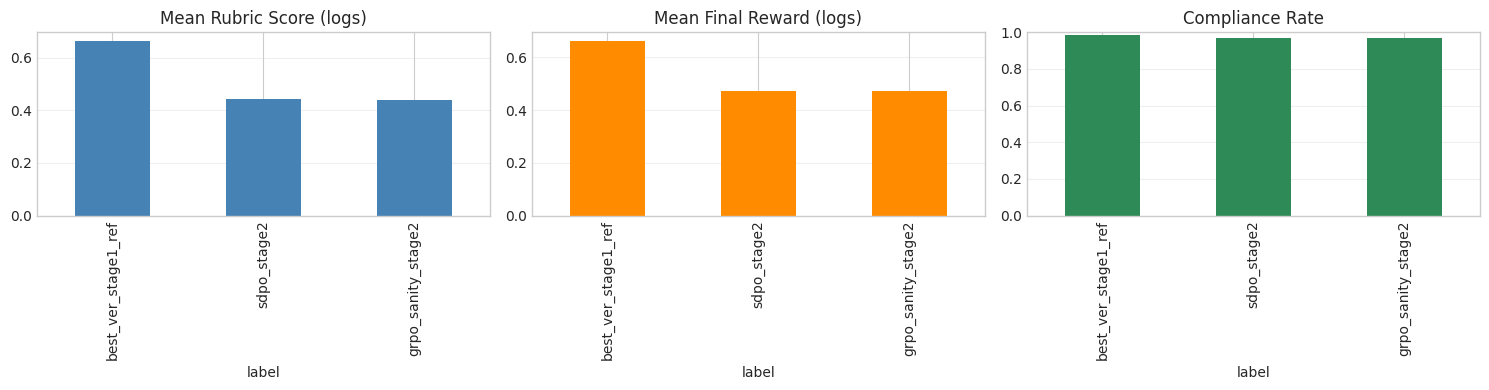

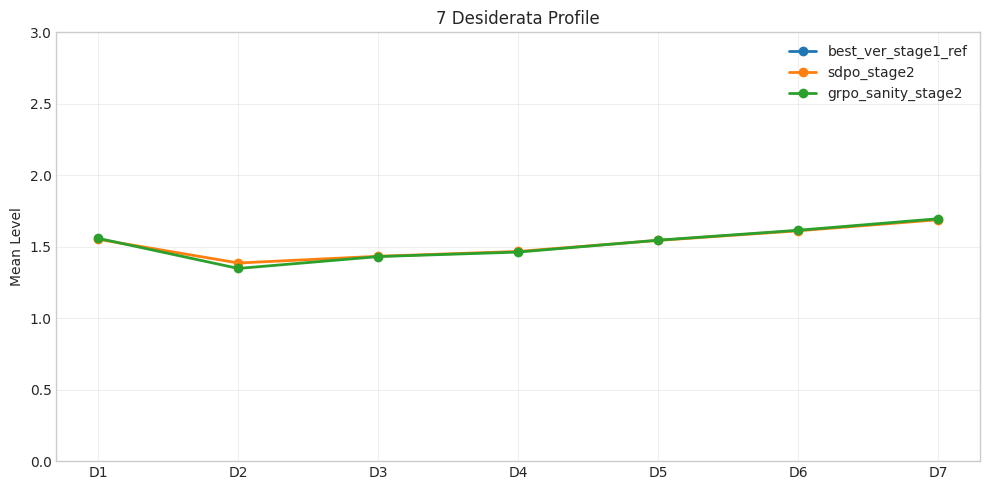

In [7]:
# Visual summary: bars + 7-desiderata profile
plot_df = summary_df.copy()
plot_df = plot_df.set_index('label')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
if 'mean_rubric_score' in plot_df.columns:
    plot_df['mean_rubric_score'].plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Mean Rubric Score (logs)')
if 'mean_final_reward' in plot_df.columns:
    plot_df['mean_final_reward'].plot(kind='bar', ax=axes[1], color='darkorange')
    axes[1].set_title('Mean Final Reward (logs)')
if 'compliance_rate' in plot_df.columns:
    plot_df['compliance_rate'].plot(kind='bar', ax=axes[2], color='seagreen')
    axes[2].set_title('Compliance Rate')
    axes[2].set_ylim(0, 1)
for ax in axes:
    ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

des_cols = [f'd{i}_mean' for i in range(1, 8) if f'd{i}_mean' in summary_df.columns]
if des_cols:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(1, len(des_cols) + 1)
    for _, row in summary_df.iterrows():
        y = [row[c] for c in des_cols]
        ax.plot(x, y, marker='o', linewidth=2, label=row['label'])
    ax.set_xticks(x)
    ax.set_xticklabels([f'D{i}' for i in x])
    ax.set_ylim(0, 3)
    ax.set_ylabel('Mean Level')
    ax.set_title('7 Desiderata Profile')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


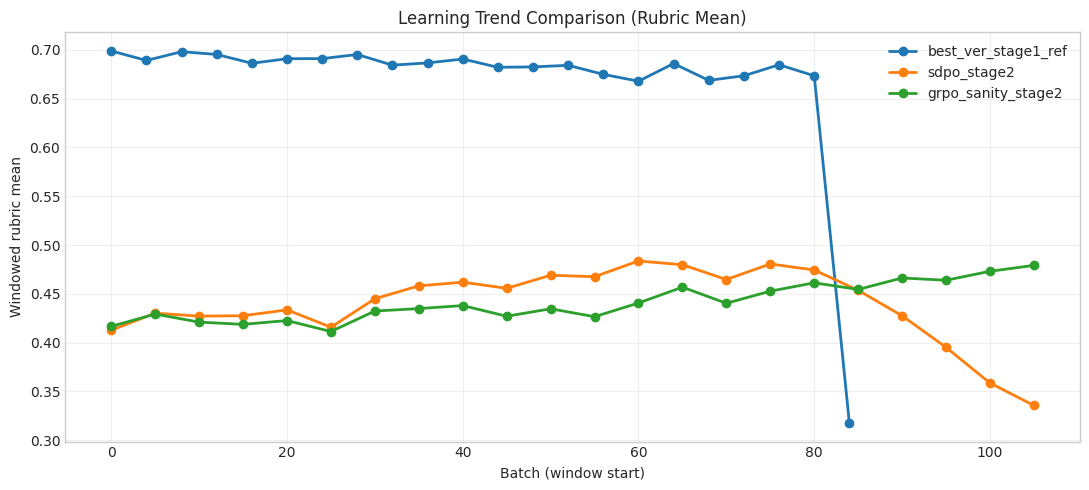

In [8]:
# Time trend (windowed rubric) for each run
def windowed(df: pd.DataFrame, value_col: str, window, auto_target=25):
    if df.empty or value_col not in df.columns:
        return pd.DataFrame(columns=['window_start_batch', 'value'])
    x = df.sort_values('batch_idx')[['batch_idx', value_col]].copy()
    if isinstance(window, str) and window.lower() == 'auto':
        w = max(1, int(np.ceil(len(x) / max(auto_target, 1))))
    else:
        w = max(1, int(window))
    min_batch = int(x['batch_idx'].min())
    x['window_id'] = ((x['batch_idx'] - min_batch) // w).astype(int)
    out = x.groupby('window_id', as_index=False).agg(window_start_batch=('batch_idx', 'min'), value=(value_col, 'mean'))
    return out

fig, ax = plt.subplots(figsize=(11, 5))
for label, d in details.items():
    bdf = d['batch_df']
    wdf = windowed(bdf, 'rubric_mean', WINDOW, AUTO_TARGET_WINDOWS)
    if wdf.empty:
        continue
    ax.plot(wdf['window_start_batch'], wdf['value'], marker='o', linewidth=2, label=label)
ax.set_xlabel('Batch (window start)')
ax.set_ylabel('Windowed rubric mean')
ax.set_title('Learning Trend Comparison (Rubric Mean)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Usage

1. In the **Config** cell, set `RUNS` to the run folders you want to compare.
2. Set `REFERENCE_LABEL` to your stage-1 baseline label (for CI deltas).
3. Start with `MAX_ROWS_PER_RUN = 80000` for fast iteration; switch to `None` for full-run benchmarking.
4. Run all cells top-to-bottom.
5. Read results in this order:
   - core benchmark table (shared metrics)
   - config parity table (checks fairness)
   - bootstrap CI table (direction + uncertainty)
   - trend + desiderata charts (behavior diagnostics)

Recommended decision rule:
- Prefer SDPO only if `rubric` and/or `reward` delta vs reference is positive with 95% CI not crossing 0,
  and compliance/trainability do not regress materially.
